## Preprocessing Data

 **PROSES CLEANING DATA**

---



In [4]:
import pandas as pd
import re
import string
import nltk

# Load dataset
data = pd.read_csv("dataset.csv")
data.info()
data.head(10)

# Copy data to df and rename column if needed
df = data.copy()
if 'text' in df.columns:
    df.rename(columns={'text': 'comment'}, inplace=True)

df.info()
df.head()

# Fungsi untuk menghapus URL
def remove_URL(tweet):
    if tweet is not None and isinstance(tweet, str):
        url = re.compile(r'https?://\S+|www\.\S+')
        return url.sub(r'', tweet)
    else:
        return tweet

# Fungsi untuk menghapus HTML
def remove_html(tweet):
    if tweet is not None and isinstance(tweet, str):
        html = re.compile(r'<.*?>')
        return html.sub(r'', tweet)
    else:
        return tweet

# Fungsi untuk menghapus emoji
def remove_emoji(tweet):
    if tweet is not None and isinstance(tweet, str):
        emoji_pattern = re.compile(
            "["
            u"\U0001F600-\U0001F64F"  # emoticons
            u"\U0001F300-\U0001F5FF"  # symbols & pictographs
            u"\U0001F680-\U0001F6FF"  # transport & map symbols
            u"\U0001F700-\U0001F77F"  # alchemical symbols
            u"\U0001F780-\U0001F7FF"  # Geometric Shapes Extended
            u"\U0001F800-\U0001F8FF"  # Supplemental Arrows-C
            u"\U0001FA00-\U0001FA6F"  # Chess Symbols
            u"\U0001FA70-\U0001FAFF"  # Symbols and Pictographs Extended-A
            u"\U0001F004-\U0001F0CF"  # Additional emoticons
            u"\U0001F1E0-\U0001F1FF"  # flags
            "]+", flags=re.UNICODE
        )
        return emoji_pattern.sub(r'', tweet)
    else:
        return tweet

# Fungsi untuk menghapus simbol
def remove_symbols(tweet):
    if tweet is not None and isinstance(tweet, str):
        tweet = re.sub(r'[^a-zA-Z0-9\s]', '', tweet)
        return tweet
    else:
        return tweet

# Fungsi untuk menghapus angka
def remove_numbers(tweet):
    if tweet is not None and isinstance(tweet, str):
        tweet = re.sub(r'\d', '', tweet)
        return tweet
    else:
        return tweet

# Fungsi hapus username
def remove_usernames(text):
    if text is not None and isinstance(text, str):
        return re.sub(r'@\w+', '', text)
    else:
        return text

# Proses cleaning
df['cleaning'] = df['comment'].apply(remove_URL)
df['cleaning'] = df['cleaning'].apply(remove_usernames)
df['cleaning'] = df['cleaning'].apply(remove_html)
df['cleaning'] = df['cleaning'].apply(remove_emoji)
df['cleaning'] = df['cleaning'].apply(remove_symbols)
df['cleaning'] = df['cleaning'].apply(remove_numbers)

df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7657 entries, 0 to 7656
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    7657 non-null   object
dtypes: object(1)
memory usage: 59.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7657 entries, 0 to 7656
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   comment  7657 non-null   object
dtypes: object(1)
memory usage: 59.9+ KB


,comment,cleaning
0,serius nanya klo gak ada dpr semua orang masih...,serius nanya klo gak ada dpr semua orang masih...
1,Menari di atas penderitaan rakyat,Menari di atas penderitaan rakyat
2,dunia akhirat gw ga iklas Byr pajak,dunia akhirat gw ga iklas Byr pajak
3,GAK USAH BAYAR PAJAK... TITIKKKK,GAK USAH BAYAR PAJAK TITIKKKK
4,parah parah pejabat indonesiaa,parah parah pejabat indonesiaa


**PROSES CASE FOLDING**

---



In [2]:
def case_folding(text):
    if isinstance(text, str):
        lowercase_text = text.lower()
        return lowercase_text
    else:
        return text

df['case_folding'] = df['cleaning'].apply(case_folding)
df.head(5)

,comment,cleaning,case_folding
0,serius nanya klo gak ada dpr semua orang masih...,serius nanya klo gak ada dpr semua orang masih...,serius nanya klo gak ada dpr semua orang masih...
1,Menari di atas penderitaan rakyat,Menari di atas penderitaan rakyat,menari di atas penderitaan rakyat
2,dunia akhirat gw ga iklas Byr pajak,dunia akhirat gw ga iklas Byr pajak,dunia akhirat gw ga iklas byr pajak
3,GAK USAH BAYAR PAJAK... TITIKKKK,GAK USAH BAYAR PAJAK TITIKKKK,gak usah bayar pajak titikkkk
4,parah parah pejabat indonesiaa,parah parah pejabat indonesiaa,parah parah pejabat indonesiaa


**PROSES NORMALISASI DATA**

---



In [3]:
import pandas as pd
import requests
from io import BytesIO

# Fungsi penggantian kata tidak baku
def replace_taboo_words(text, kamus_tidak_baku):
    if isinstance(text, str):
        words = text.split()
        replaced_words = []
        kalimat_baku = []
        kata_diganti = []
        kata_tidak_baku_hash = []

        for word in words:
            if word in kamus_tidak_baku:
                baku_word = kamus_tidak_baku[word]
                if isinstance(baku_word, str) and all(char.isalpha() for char in baku_word):
                    replaced_words.append(baku_word)
                    kalimat_baku.append(baku_word)
                    kata_diganti.append(word)
                    kata_tidak_baku_hash.append(hash(word))
            else:
                replaced_words.append(word)
        replaced_text = ' '.join(replaced_words)
    else:
        replaced_text = ''
        kalimat_baku = []
        kata_diganti = []
        kata_tidak_baku_hash = []

    return replaced_text, kalimat_baku, kata_diganti, kata_tidak_baku_hash

# Baca dataset kamu (pastikan df sudah tersedia)
data = pd.DataFrame(df[['comment','cleaning','case_folding']])
data.head()

,comment,cleaning,case_folding
0,serius nanya klo gak ada dpr semua orang masih...,serius nanya klo gak ada dpr semua orang masih...,serius nanya klo gak ada dpr semua orang masih...
1,Menari di atas penderitaan rakyat,Menari di atas penderitaan rakyat,menari di atas penderitaan rakyat
2,dunia akhirat gw ga iklas Byr pajak,dunia akhirat gw ga iklas Byr pajak,dunia akhirat gw ga iklas byr pajak
3,GAK USAH BAYAR PAJAK... TITIKKKK,GAK USAH BAYAR PAJAK TITIKKKK,gak usah bayar pajak titikkkk
4,parah parah pejabat indonesiaa,parah parah pejabat indonesiaa,parah parah pejabat indonesiaa


In [4]:
# Unduh dan baca kamus dari GitHub
url = "https://github.com/analysisdatasentiment/kamus_kata_baku/raw/main/kamuskatabaku.xlsx"
response = requests.get(url)
file_excel = BytesIO(response.content)
kamus_data = pd.read_excel(file_excel)

# Buat dictionary dari kamus
kamus_tidak_baku_dict = dict(zip(kamus_data['tidak_baku'], kamus_data['kata_baku']))

In [5]:
# Terapkan fungsi normalisasi
data[['normalisasi', 'Kata_Baku', 'Kata_Tidak_Baku', 'Kata_Tidak_Baku_Hash']] = data['case_folding'].apply(
    lambda x: pd.Series(replace_taboo_words(x, kamus_tidak_baku_dict))
)

# Ambil kolom yang relevan
df = pd.DataFrame(data[['comment','cleaning','case_folding','normalisasi']])
df.head(5)

df.to_csv("newpreprocessed_dataset.csv", index=False)
print("Preprocessed dataset saved to 'newpreprocessed_dataset.csv'")

Preprocessed dataset saved to 'newpreprocessed_dataset.csv'


In [6]:
import pandas as pd

data = pd.read_csv("newpreprocessed_dataset.csv")
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7657 entries, 0 to 7656
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   comment       7657 non-null   object
 1   cleaning      7657 non-null   object
 2   case_folding  7657 non-null   object
 3   normalisasi   7649 non-null   object
dtypes: object(4)
memory usage: 239.4+ KB


,comment,cleaning,case_folding,normalisasi
0,serius nanya klo gak ada dpr semua orang masih...,serius nanya klo gak ada dpr semua orang masih...,serius nanya klo gak ada dpr semua orang masih...,serius bertanya kalau tidak ada dpr semua oran...
1,Menari di atas penderitaan rakyat,Menari di atas penderitaan rakyat,menari di atas penderitaan rakyat,menari di atas penderitaan rakyat
2,dunia akhirat gw ga iklas Byr pajak,dunia akhirat gw ga iklas Byr pajak,dunia akhirat gw ga iklas byr pajak,dunia akhirat gue tidak iklas byr pajak
3,GAK USAH BAYAR PAJAK... TITIKKKK,GAK USAH BAYAR PAJAK TITIKKKK,gak usah bayar pajak titikkkk,tidak usah bayar pajak titikkkk
4,parah parah pejabat indonesiaa,parah parah pejabat indonesiaa,parah parah pejabat indonesiaa,parah parah pejabat indonesiaa


In [7]:
data = data.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7649 entries, 0 to 7656
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   comment       7649 non-null   object
 1   cleaning      7649 non-null   object
 2   case_folding  7649 non-null   object
 3   normalisasi   7649 non-null   object
dtypes: object(4)
memory usage: 298.8+ KB


In [8]:
data = pd.DataFrame(data[['normalisasi']])
data.head(5)

,normalisasi
0,serius bertanya kalau tidak ada dpr semua oran...
1,menari di atas penderitaan rakyat
2,dunia akhirat gue tidak iklas byr pajak
3,tidak usah bayar pajak titikkkk
4,parah parah pejabat indonesiaa


## Labeling Data

In [ ]:
import pandas as pd
import requests

# Kamus lexicon positif dan negatif dari GitHub
positive_url = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
negative_url = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"

positive_lexicon = set(pd.read_csv(positive_url, sep="\t", header=None)[0])
negative_lexicon = set(pd.read_csv(negative_url, sep="\t", header=None)[0])

# Fungsi untuk menentukan sentimen dan menghitung skornya
def determine_sentiment(text):
    if isinstance(text, str):
        positive_count = sum(1 for word in text.split() if word in positive_lexicon)
        negative_count = sum(1 for word in text.split() if word in negative_lexicon)
        sentiment_score = positive_count - negative_count
        if sentiment_score > 0:
            sentiment = "Positif"
        elif sentiment_score < 0:
            sentiment = "Negatif"
        else:
            sentiment = "Netral"
        return sentiment_score, sentiment
    return 0, "Netral"


# Tentukan sentimen dan skor untuk setiap ulasan
data[['Score', 'Sentiment']] = data['normalisasi'].apply(lambda x: pd.Series(determine_sentiment(x)))

# Tampilkan hasilnya
data.head(20)

,normalisasi,Score,Sentiment
0,serius bertanya kalau tidak ada dpr semua oran...,-3,Negatif
1,menari di atas penderitaan rakyat,-2,Negatif
2,dunia akhirat gue tidak iklas byr pajak,-2,Negatif
3,tidak usah bayar pajak titikkkk,-3,Negatif
4,parah parah pejabat indonesiaa,-3,Negatif
5,rakyat sengsara anggota dpr bahagia,-2,Negatif
6,bantuan listrik sumpah demi allah sakit hati d...,2,Positif
7,demi allah saya tidak ikhlas dunia akhirat gaj...,-2,Negatif
8,ini orang orang prabowo pejabat makin kayak ra...,-1,Negatif
9,pantesan pada rebutan kursi dpr sampai nyuap r...,-4,Negatif


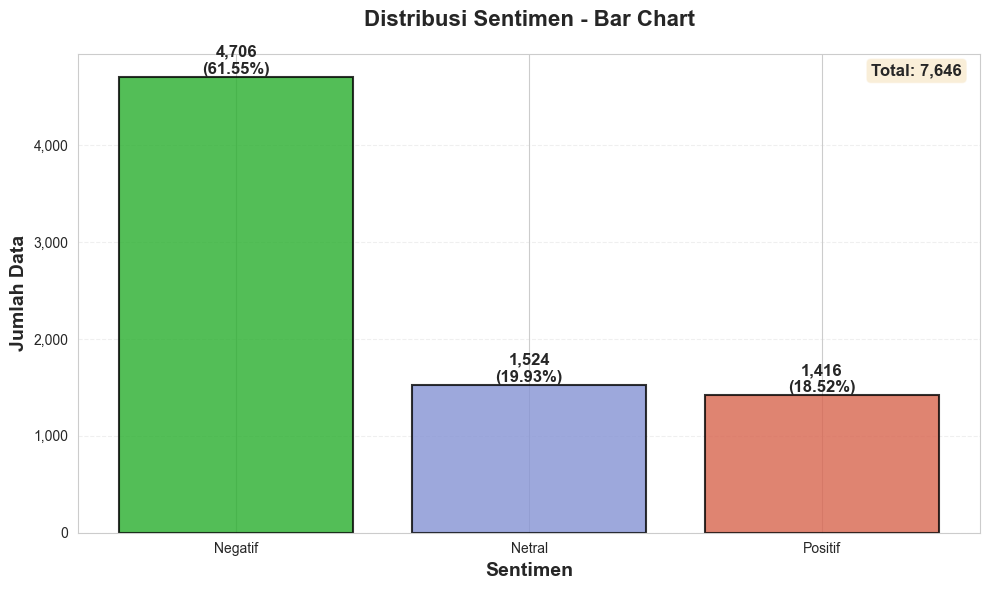

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("lexicon_label.csv")

sentiment_count = data['Sentiment'].value_counts()
total = len(data['Sentiment'])

# Set style
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

# Warna yang sama dengan donut chart
colors = ["#28AE2D", "#8593D4", "#D8654E"]  # Positif, Netral, Negatif

# Buat bar chart
bars = ax.bar(
    sentiment_count.index, 
    sentiment_count.values,
    color=colors,
    edgecolor='black',
    linewidth=1.5,
    alpha=0.8
)

# Tambahkan nilai di atas setiap bar
for i, (bar, count) in enumerate(zip(bars, sentiment_count.values)):
    height = bar.get_height()
    percentage = (count / total) * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{count:,}\n({percentage:.2f}%)',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

# Styling
ax.set_xlabel('Sentimen', fontsize=14, fontweight='bold')
ax.set_ylabel('Jumlah Data', fontsize=14, fontweight='bold')
ax.set_title('Distribusi Sentimen - Bar Chart', fontsize=16, fontweight='bold', pad=20)

# Format y-axis dengan koma untuk ribuan
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Grid
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Tambahkan total di pojok kanan atas
ax.text(
    0.98, 0.98, 
    f'Total: {total:,}',
    transform=ax.transAxes,
    fontsize=12,
    fontweight='bold',
    va='top',
    ha='right',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
)

plt.tight_layout()
plt.show()

In [11]:
data.to_csv('lexicon_label.csv',encoding='utf8', index=False)

In [4]:
# Simpan data yang sudah di-oversampling
data_balanced.to_csv('dataset_balanced.csv', encoding='utf8', index=False)
print("✓ Data yang sudah di-oversampling berhasil disimpan ke 'dataset_balanced.csv'")

✓ Data yang sudah di-oversampling berhasil disimpan ke 'dataset_balanced.csv'


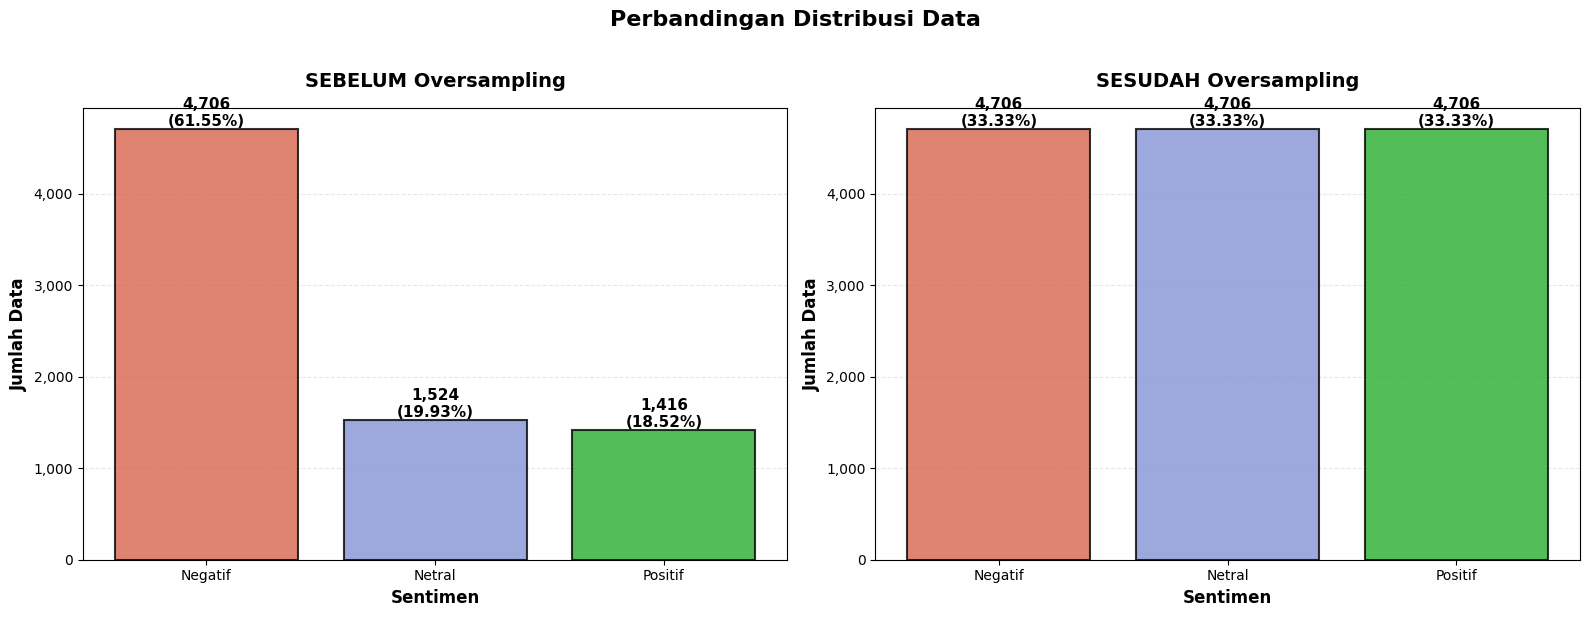

In [3]:
# Visualisasi perbandingan sebelum dan sesudah oversampling
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Warna yang konsisten
colors = ["#D8654E", "#8593D4", "#28AE2D"]  # Negatif, Netral, Positif

# Bar chart SEBELUM oversampling
sentiment_before = data['Sentiment'].value_counts().sort_index()
bars1 = ax1.bar(sentiment_before.index, sentiment_before.values, color=colors, 
                edgecolor='black', linewidth=1.5, alpha=0.8)

for bar, count in zip(bars1, sentiment_before.values):
    height = bar.get_height()
    percentage = (count / len(data)) * 100
    ax1.text(bar.get_x() + bar.get_width() / 2, height,
             f'{count:,}\n({percentage:.2f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.set_xlabel('Sentimen', fontsize=12, fontweight='bold')
ax1.set_ylabel('Jumlah Data', fontsize=12, fontweight='bold')
ax1.set_title('SEBELUM Oversampling', fontsize=14, fontweight='bold', pad=15)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)

# Bar chart SESUDAH oversampling
sentiment_after = data_balanced['Sentiment'].value_counts().sort_index()
bars2 = ax2.bar(sentiment_after.index, sentiment_after.values, color=colors,
                edgecolor='black', linewidth=1.5, alpha=0.8)

for bar, count in zip(bars2, sentiment_after.values):
    height = bar.get_height()
    percentage = (count / len(data_balanced)) * 100
    ax2.text(bar.get_x() + bar.get_width() / 2, height,
             f'{count:,}\n({percentage:.2f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2.set_xlabel('Sentimen', fontsize=12, fontweight='bold')
ax2.set_ylabel('Jumlah Data', fontsize=12, fontweight='bold')
ax2.set_title('SESUDAH Oversampling', fontsize=14, fontweight='bold', pad=15)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)

plt.suptitle('Perbandingan Distribusi Data', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [2]:
# Pisahkan data berdasarkan sentimen
df_negatif = data[data['Sentiment'] == 'Negatif']
df_netral = data[data['Sentiment'] == 'Netral']
df_positif = data[data['Sentiment'] == 'Positif']

# Tentukan jumlah maksimal (kelas mayoritas)
max_count = max(len(df_negatif), len(df_netral), len(df_positif))

print(f"\nTarget jumlah data per kelas (maksimal): {max_count:,}")

# Lakukan oversampling untuk setiap kelas hingga mencapai max_count
df_negatif_upsampled = resample(df_negatif, 
                                 replace=True,  # sample dengan penggantian
                                 n_samples=max_count,  # jumlah target
                                 random_state=42)

df_netral_upsampled = resample(df_netral, 
                                replace=True,
                                n_samples=max_count,
                                random_state=42)

df_positif_upsampled = resample(df_positif, 
                                 replace=True,
                                 n_samples=max_count,
                                 random_state=42)

# Gabungkan semua data yang sudah di-oversampling
data_balanced = pd.concat([df_negatif_upsampled, df_netral_upsampled, df_positif_upsampled])

# Shuffle data
data_balanced = data_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Cek distribusi setelah oversampling
print("\n" + "=" * 60)
print("DISTRIBUSI DATA SETELAH OVERSAMPLING")
print("=" * 60)
sentiment_counts_balanced = data_balanced['Sentiment'].value_counts()
print(sentiment_counts_balanced)
print(f"\nTotal data: {len(data_balanced):,}")
print("\nPersentase:")
for sentiment, count in sentiment_counts_balanced.items():
    print(f"{sentiment}: {count:,} ({count/len(data_balanced)*100:.2f}%)")
print("=" * 60)

data_balanced.head(10)


Target jumlah data per kelas (maksimal): 4,706

DISTRIBUSI DATA SETELAH OVERSAMPLING
Sentiment
Positif    4706
Negatif    4706
Netral     4706
Name: count, dtype: int64

Total data: 14,118

Persentase:
Positif: 4,706 (33.33%)
Negatif: 4,706 (33.33%)
Netral: 4,706 (33.33%)


,normalisasi,Score,Sentiment
0,mana buktinya penjelasan tanpa transparasi sam...,2,Positif
1,kalau harga beras segonikg harganya ribu maka ...,1,Positif
2,sila ke keadilan sosial bagi seluruh rakyat in...,1,Positif
3,sama sakit hati banget,1,Positif
4,kernya mereka naikin pajak biar upah mereka be...,-2,Negatif
5,nah ini yang jadi beban rakyat,-2,Negatif
6,nih makluk dimana ada,0,Netral
7,mau ku lacak tidak nih orang,-1,Negatif
8,percaya bertanya dengan nada rendah dan pelan,2,Positif
9,jangan di ramaikan teman nanti dia viral terke...,-6,Negatif


In [1]:
import pandas as pd
from sklearn.utils import resample
import matplotlib.pyplot as plt
import seaborn as sns

# Load data yang sudah dilabeling
data = pd.read_csv("lexicon_label.csv")

# Cek distribusi data sebelum oversampling
print("=" * 60)
print("DISTRIBUSI DATA SEBELUM OVERSAMPLING")
print("=" * 60)
sentiment_counts = data['Sentiment'].value_counts()
print(sentiment_counts)
print(f"\nTotal data: {len(data):,}")
print("\nPersentase:")
for sentiment, count in sentiment_counts.items():
    print(f"{sentiment}: {count:,} ({count/len(data)*100:.2f}%)")
print("=" * 60)

DISTRIBUSI DATA SEBELUM OVERSAMPLING
Sentiment
Negatif    4706
Netral     1524
Positif    1416
Name: count, dtype: int64

Total data: 7,646

Persentase:
Negatif: 4,706 (61.55%)
Netral: 1,524 (19.93%)
Positif: 1,416 (18.52%)


## Oversampling Data

Melakukan oversampling untuk mengatasi ketidakseimbangan data (imbalanced data)

## IndoBERT Fine-Tuned

In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from transformers import DataCollatorWithPadding
from datasets import Dataset

# Load data
df = pd.read_csv("lexicon_label.csv")

df.info()
df.head(5)

KeyboardInterrupt: 

In [2]:
df = df.dropna(subset=['normalisasi', 'Sentiment'])
# df = df[:1000]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7646 entries, 0 to 7645
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   normalisasi  7646 non-null   object
 1   Score        7646 non-null   int64 
 2   Sentiment    7646 non-null   object
dtypes: int64(1), object(2)
memory usage: 179.3+ KB


In [3]:
# Encode label jika belum numerik
if df['Sentiment'].dtype == 'object':
    df['Sentiment'] = df['Sentiment'].astype('category').cat.codes

# Split data 80:10:10 (train:validation:test)
# Pertama split 80:20
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)

# Kemudian split 20% menjadi 10:10 (validation:test)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

# Verifikasi proporsi
print(f"Train size: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
print(f"Validation size: {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test size: {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")

Train size: 6116 (80.0%)
Validation size: 765 (10.0%)
Test size: 765 (10.0%)


In [4]:
# Tokenizer IndoBERT
tokenizer = BertTokenizer.from_pretrained("indobenchmark/indobert-base-p1")

def tokenize_function(example):
    return {
        **tokenizer(example["normalisasi"], truncation=True),
        'labels': example['Sentiment']
    }

train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map: 100%|██████████| 765/765 [00:00<00:00, 6249.19 examples/s]


In [22]:
pip install transformers[torch] accelerate>=0.26.0

Note: you may need to restart the kernel to use updated packages.


In [23]:
# Load IndoBERT for classification
model = BertForSequenceClassification.from_pretrained("indobenchmark/indobert-base-p1", num_labels=df['Sentiment'].nunique())

# Training arguments dengan hyperparameter yang lebih optimal
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,  # Baik untuk BERT (bisa coba: 3e-5, 5e-5)
    per_device_train_batch_size=8,  # Naikkan jika memori cukup (8 -> 16)
    per_device_eval_batch_size=32,  # Naikkan untuk evaluasi lebih cepat
    num_train_epochs=3,  # Kurangi dari 5 ke 3 untuk mencegah overfitting
    weight_decay=0.01,  # Baik untuk regularisasi
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_dir="./logs",
    logging_steps=10,
    warmup_steps=500,  # Tambahkan warmup untuk stabilitas
    gradient_accumulation_steps=2,  # Tambahkan jika batch size kecil
    fp16=True,  # Aktifkan mixed precision jika GPU support
    save_total_limit=2,  # Batasi jumlah checkpoint yang disimpan
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


In [24]:
# Fungsi untuk menghitung metrik lebih lengkap
from sklearn.metrics import precision_recall_fscore_support

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    # Hitung accuracy
    accuracy = accuracy_score(labels, predictions)
    
    # Hitung precision, recall, f1-score
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='weighted'
    )
    
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# Inisialisasi Trainer dengan validation dataset
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

C:\Users\sheva\AppData\Local\Temp\ipykernel_19148\2448356164.py:24: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [27]:
# ===== TAMBAHKAN CLASS WEIGHTS =====
from sklearn.utils.class_weight import compute_class_weight

# 1. Hitung class weights dari training data
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['Sentiment']),
    y=train_df['Sentiment']
)

print("=" * 50)
print("CLASS WEIGHTS")
print("=" * 50)
for i, weight in enumerate(class_weights):
    print(f"Class {i}: {weight:.4f}")
print("=" * 50)

# 2. Custom Trainer dengan Weighted Loss (UPDATED SIGNATURE)
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        """
        Custom loss function dengan class weights
        
        Args:
            model: Model yang sedang di-training
            inputs: Dictionary berisi input data
            return_outputs: Boolean untuk return outputs atau tidak
            num_items_in_batch: Jumlah item dalam batch (parameter baru di Transformers >= 4.30)
        """
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        
        # Gunakan CrossEntropyLoss dengan class weights
        loss_fct = torch.nn.CrossEntropyLoss(
            weight=torch.tensor(class_weights, dtype=torch.float).to(logits.device)
        )
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        
        return (loss, outputs) if return_outputs else loss

# 3. Ganti Trainer biasa dengan WeightedTrainer
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("\n✓ Trainer dengan class weights berhasil diinisialisasi!")

CLASS WEIGHTS
Class 0: 0.5428
Class 1: 1.6710
Class 2: 1.7883

✓ Trainer dengan class weights berhasil diinisialisasi!


C:\Users\sheva\AppData\Local\Temp\ipykernel_19148\3138747768.py:43: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  trainer = WeightedTrainer(


In [28]:
# Train model
trainer.train()

d:\Data\Kuliah\Semester 7\Skripsi\tiktok-indobert\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.713800,0.784828,0.717647,0.726485,0.717647,0.720590
2,0.554000,0.696091,0.788235,0.778237,0.788235,0.780975
3,0.345600,0.608347,0.786928,0.816531,0.786928,0.797745


d:\Data\Kuliah\Semester 7\Skripsi\tiktok-indobert\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
d:\Data\Kuliah\Semester 7\Skripsi\tiktok-indobert\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=1149, training_loss=0.6358976828937846, metrics={'train_runtime': 1976.5628, 'train_samples_per_second': 9.283, 'train_steps_per_second': 0.581, 'total_flos': 326513473532568.0, 'train_loss': 0.6358976828937846, 'epoch': 3.0})

In [29]:
# 1. Evaluasi model pada test dataset
test_results = trainer.predict(test_dataset)
test_predictions = np.argmax(test_results.predictions, axis=1)
test_labels = test_results.label_ids

d:\Data\Kuliah\Semester 7\Skripsi\tiktok-indobert\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [30]:
# 2. Hitung metrik evaluasi
print("=" * 50)
print("HASIL EVALUASI PADA TEST SET")
print("=" * 50)
print(f"\nAccuracy: {accuracy_score(test_labels, test_predictions):.4f}")
print("\nClassification Report:")
print(classification_report(test_labels, test_predictions, target_names=['Negatif', 'Netral', 'Positif']))

HASIL EVALUASI PADA TEST SET

Accuracy: 0.7908

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.82      0.95      0.88       465
      Netral       0.59      0.44      0.51       157
     Positif       0.84      0.67      0.75       143

    accuracy                           0.79       765
   macro avg       0.75      0.69      0.71       765
weighted avg       0.78      0.79      0.78       765



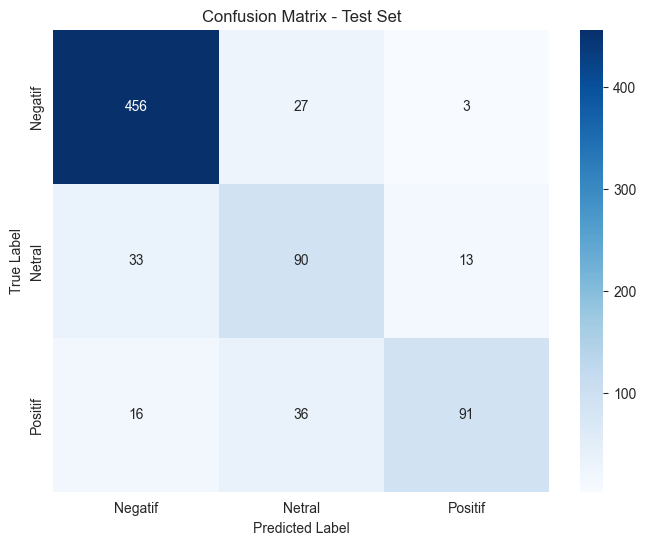

In [23]:
# 3. Confusion Matrix
cm = confusion_matrix(test_labels, test_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negatif', 'Netral', 'Positif'],
            yticklabels=['Negatif', 'Netral', 'Positif'])
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()